In [1]:
# !pip install sgp4
# !pip install pymap3d

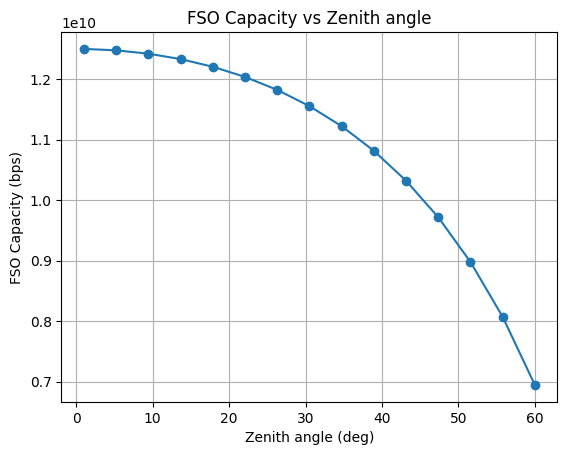

In [1]:
import numpy as np
import math
from scipy.integrate import quad
import matplotlib.pyplot as plt

stratos = 2e-2
H_st = 28  # km
sigma_Rdx  = 1
sigma_Rdy = 1
theta_Sxy = 0.3e-6
muy_Rx = 0
muy_Ry = 0
lambd = 1550e-9
theta = 10e-6

def stratos_atten(stratos, H_st, zenith_angle):
    sec = 1 / np.cos(np.deg2rad(zenith_angle))
    return np.exp(-stratos * H_st * sec)



def pointing_error(slant_path, lambd, theta, Dr):
    k_wave = 2 * np.pi / lambd
    d = slant_path
    w0 = 2 * lambd / (np.pi * theta)          # Beam waist
    Theta_0 = 1
    Lambda_0 = (2 * d) / (k_wave * w0**2)
    w_L = w0 * np.sqrt((Theta_0**2 + Lambda_0**2))  
    v = (np.sqrt(np.pi) * (Dr/2)) / (np.sqrt(2) * w_L)
    A0 = (math.erf(v))**2
    w_Leq = w_L*np.sqrt((np.sqrt(np.pi) * math.erf(v))/(2*v*np.exp(-v**2)))

    sigma_Sx = theta_Sxy * slant_path
    sigma_Sy = theta_Sxy * slant_path
    sigma2_Rx = sigma_Rdx**2 + sigma_Sx**2
    sigma2_Ry = sigma_Rdy**2 + sigma_Sy**2
    sigma_Rx = np.sqrt(sigma2_Rx)
    sigma_Ry = np.sqrt(sigma2_Ry)
    sigma2_Rmod = ((3*(muy_Rx**2)*(sigma_Rx**4) + 3*(muy_Ry**2)*(sigma_Ry**4) 
                    + sigma_Rx**6 + sigma_Ry**6)/2)**(1/3)
    sigma_Rmod = np.sqrt(sigma2_Rmod)

    phi_mod = w_Leq / (2*sigma_Rmod)
    phi_Rx = w_Leq / (2*sigma_Rx)
    phi_Ry = w_Leq / (2*sigma_Ry)
    A_mod = A0 * np.exp(1/(phi_mod**2) - 1/(2*phi_Rx**2) - 1/(2*phi_Ry**2) 
                         - muy_Rx**2/(2*sigma_Rx**2*phi_Rx**2) 
                         - muy_Ry**2/(2*sigma_Ry**2*phi_Ry**2))
    
    return A_mod, phi_mod

def noise(gamma, slant_path, theta, Dr, zenith_angle):
    A_mod, phi_mod = pointing_error(slant_path, lambd, theta, Dr)
    Ha = stratos_atten(stratos, H_st, zenith_angle)
    Pt_FSO_dBm = 15
    Pt_FSO = 10 ** ((Pt_FSO_dBm - 30) / 10)
    sigma_n = 1e-7

    persi = 0.9**2 * Pt_FSO**2 / (sigma_n)**2
    return (phi_mod**2 / (2*gamma*(A_mod*Ha)**(phi_mod**2))) * ((gamma/persi)**((phi_mod**2)/2))

def C_FSO(slant_path,zenith_angle, theta = 20e-6, Dr = 0.08 ):
    B_FSO = 1200e6
    slant_path = slant_path / np.cos(np.deg2rad(zenith_angle))  

    A_mod, phi_mod = pointing_error(slant_path, lambd, theta, Dr)
    Ha = stratos_atten(stratos, H_st, zenith_angle)
    Pt_FSO_dBm = 15
    Pt_FSO = 10 ** ((Pt_FSO_dBm - 30) / 10)
    sigma_n = 1e-7
    Psi = (0.9*Pt_FSO/sigma_n)**2
    
    gamma_max =  Psi*(A_mod * Ha)**2  
    # print(gamma_max)
    integrand = lambda gamma: B_FSO*np.log2(1 + gamma) * noise(gamma, slant_path, theta, Dr, zenith_angle)
    result, _ = quad(integrand, 1e-9, gamma_max, limit=500)
    return result

slant_path = 300000

zenith_angles = np.linspace(1, 60, 15)   
capacities = [C_FSO(slant_path,  z) for z in zenith_angles]

plt.plot(zenith_angles, capacities, marker="o")
plt.xlabel("Zenith angle (deg)")
plt.ylabel("FSO Capacity (bps)")
plt.title("FSO Capacity vs Zenith angle")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sgp4.api import Satrec, jday
import pymap3d as pm
import concurrent.futures
import os, time
import sys, os
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
# from network_models.backhaul_satHAP import *
EARTH_R_KM = 6371.0

def gst_from_jd_array(jd_full):
    T = (jd_full - 2451545.0) / 36525.0
    gst_deg = (280.46061837 +
               360.98564736629 * (jd_full - 2451545.0) +
               0.000387933 * T**2 -
               (T**3)/38710000.0)
    gst_deg = np.mod(gst_deg, 360.0)
    return np.deg2rad(gst_deg)

def eci_to_ecef_vectorized(r_eci_km, jd, fr_array):
    jd_full = jd + fr_array
    gst = gst_from_jd_array(jd_full)
    x, y, z = r_eci_km[:,0], r_eci_km[:,1], r_eci_km[:,2]
    cos_g, sin_g = np.cos(gst), np.sin(gst)
    xe = x*cos_g + y*sin_g
    ye = -x*sin_g + y*cos_g
    ze = z.copy()
    return np.stack([xe, ye, ze], axis=1) * 1000.0  # m

def compute_elevation_and_slant(sat_ecef, obs_ecef, lat_obs, lon_obs, alt_obs_m):
    x, y, z = sat_ecef[:,0], sat_ecef[:,1], sat_ecef[:,2]
    east, north, up = pm.ecef2enu(x, y, z, lat_obs, lon_obs, alt_obs_m)
    hor_dist = np.sqrt(east**2 + north**2)
    elev = np.degrees(np.arctan2(up, hor_dist))
    slant = np.sqrt((x-obs_ecef[0])**2 + (y-obs_ecef[1])**2 + (z-obs_ecef[2])**2)
    return elev, slant


def compute_top10_visible_times(elevations, masks, slants, times, topk=10):
    n_steps = len(times)
    result = {}
    for t in range(n_steps):
        sat_list = []
        for sat, elev_arr in elevations.items():
            if masks[sat][t] and elev_arr[t] > 0:
                sat_list.append((sat, elev_arr[t]))
        
        if not sat_list:  # không có vệ tinh nào
            result[t] = []  # hoặc result[t] = None tuỳ nhu cầu
            continue

        sat_list.sort(key=lambda x: x[1], reverse=True)
        top_sats = sat_list[:topk]

        out = []
        for sat, elev in top_sats:
            vt = 0
            for k in range(t, n_steps):
                if masks[sat][k] and elevations[sat][k] > 0:
                    vt += 1
                else:
                    break
            slant_val = slants[sat][t] if sat in slants else np.nan
            out.append((sat, elev, vt, slant_val))

        result[t] = out
    return result
def compute_all_visible_times(elevations, masks, slants, times):
    
    n_steps = len(times)
    result = {}

    for t in range(n_steps):
        sat_list = []
        for sat, elev_arr in elevations.items():
            if masks[sat][t] and elev_arr[t] > 0:
                sat_list.append(sat)
        
        if not sat_list:
            result[t] = []
            continue

        out = []
        for sat in sat_list:
            elev = elevations[sat][t]
            
            # tính thời gian liên tục có thể nhìn thấy từ step t
            vt = 0
            for k in range(t, n_steps):
                if masks[sat][k] and elevations[sat][k] > 0:
                    vt += 1
                else:
                    break
            
            slant_val = slants[sat][t] if sat in slants else np.nan
            out.append((sat, elev, vt, slant_val))

        result[t] = out

    return result

def draw_2D_sat_fast_opt(tle_file,
                         lat_obs=35.6762, lon_obs=139.6503, alt_obs_m=20000,
                         beam_radius_km=500,
                         start_jd_tuple=(2025,8,17,9,0,0),
                         total_seconds=86400, n_samples=86400,
                         use_parallel=True, max_workers=None,
                         verbose=True):
    
    sats = []
    with open(tle_file, "r") as f:
        lines = [ln.rstrip("\n") for ln in f.readlines()]
    i = 0
    while i < len(lines)-1:
        if lines[i].startswith("1 ") and lines[i+1].startswith("2 "):
            name = f"NO_NAME_{i}"
            sats.append((name, lines[i], lines[i+1]))
            i += 2; continue
        if i+2 < len(lines) and lines[i+1].startswith("1 ") and lines[i+2].startswith("2 "):
            name = lines[i]
            sats.append((name, lines[i+1], lines[i+2]))
            i += 3; continue
        i += 1

    n_sats = len(sats)
    # if verbose: print(f"Loaded {n_sats} TLE blocks from {tle_file}")

    jd, fr = jday(*start_jd_tuple)
    times = np.linspace(0.0, float(total_seconds), int(n_samples))
    fr_array = fr + times/86400.0
    jd_array = np.full_like(fr_array, jd, dtype=np.float64)

    obs_x, obs_y, obs_z = pm.geodetic2ecef(lat_obs, lon_obs, alt_obs_m)
    obs_vec = np.array([obs_x, obs_y, obs_z], dtype=float)

    beam_angle_rad = beam_radius_km / EARTH_R_KM
    cos_beam = np.cos(beam_angle_rad)

    cover_counts = np.zeros(len(times), dtype=int)
    masks, elevations, slants, sats_dict = {}, {}, {}, {}

    def process_one_sat(block):
        name, l1, l2 = block
        try:
            sat = Satrec.twoline2rv(l1, l2)
            e, r_km, v = sat.sgp4_array(jd_array, fr_array)
        except:
            return None

        ok = (e == 0)
        if not np.any(ok):
            return None

        r_valid, fr_valid = r_km[ok], fr_array[ok]
        r_ecef_m = eci_to_ecef_vectorized(r_valid, jd, fr_valid)

        norms = np.linalg.norm(r_ecef_m, axis=1, keepdims=True)
        sat_unit = r_ecef_m / norms
        obs_unit = obs_vec / np.linalg.norm(obs_vec)
        cos_angles = sat_unit.dot(obs_unit)

        mask = np.zeros(len(times), dtype=bool)
        mask_idx = np.nonzero(ok)[0]
        mask[mask_idx] = (cos_angles >= cos_beam)

        elev_full = np.full(len(times), np.nan)
        slant_full = np.full(len(times), np.nan)
        elev_val, slant_val = compute_elevation_and_slant(
            r_ecef_m, obs_vec, lat_obs, lon_obs, alt_obs_m
        )
        elev_full[mask_idx] = elev_val
        slant_full[mask_idx] = slant_val

        mask[mask_idx] &= (elev_val > 30)

        return name, mask, elev_full, slant_full, r_ecef_m

    # t0 = time.time()
    if use_parallel:
        max_workers = max_workers or min(32, (os.cpu_count() or 1))
        # if verbose: print(f"Processing {n_sats} satellites with workers={max_workers} ...")
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(process_one_sat, block) for block in sats]
            for i, fut in enumerate(concurrent.futures.as_completed(futures), 1):
                try:
                    res = fut.result()
                    if res:
                        name, mask, elev, slant, r_ecef_m = res
                        # name, mask, elev, slant = res
                        cover_counts += mask.astype(int)
                        masks[name] = mask
                        elevations[name] = elev
                        slants[name] = slant
                        sats_dict[name] = r_ecef_m
                except: pass
                if verbose and i % 200 == 0:
                    print(f"  processed {i}/{n_sats}")
                    continue
    else:
        for i, block in enumerate(sats, start=1):
            res = process_one_sat(block)
            if res:
                name, mask, elev, slant = res
                cover_counts += mask.astype(int)
                masks[name] = mask
                elevations[name] = elev
                slants[name] = slant
            if verbose and (i % 200 == 0):
                # print(f"  processed {i}/{n_sats}")
                continue


    plt.figure(figsize=(10,5))
    plt.plot(times/60.0, cover_counts, marker='o')
    plt.xlabel("Time (minutes)")
    plt.ylabel("Number of satellites")
    plt.title(f"Coverage (beam radius {beam_radius_km} km) — samples={len(times)} sats={n_sats}")
    plt.grid(True)
    plt.show()

    top_vis = compute_all_visible_times(elevations, masks, slants, times)

    return times, cover_counts, top_vis, sats, elevations, slants, sats_dict
import random

def get_sat():
    time = random.randint(0, 86400)
    start_jd_tuple = (2025, 8, 17, 9, 0, 0)
    start_time = datetime(*start_jd_tuple)

    rand_seconds = random.randint(0, 86400)
    new_time = start_time + timedelta(seconds=rand_seconds)

    new_tuple = (new_time.year, new_time.month, new_time.day,
                new_time.hour, new_time.minute, new_time.second)
    _, _, top_10, _, _, _, sats_dict = draw_2D_sat_fast_opt("STARLINK.txt", start_jd_tuple=new_tuple)
    results_per_step = {}
    for t_idx, top_list in top_10.items():
        step_results = []
        for sat_name, elev, vt, slant in top_list:
            # print(sat_name, elev, vt, slant)
            coord = sats_dict[sat_name][t_idx]   # (x, y, z) tại step t_idx
            east, north, up = pm.ecef2enu(
                            coord[0], coord[1], coord[2],
                            35.6762, 139.6503, 20000
                        )

            your_result = C_FSO(slant, 90 - elev)/(1.1e10)
            step_results.append(
                (sat_name, elev, vt, slant, your_result, (east, north, up))
            )
         

        results_per_step[t_idx] = step_results
    return results_per_step


def draw_2D_sat_fast_opt_figure(tle_file,
                         lat_obs=35.6762, lon_obs=139.6503, alt_obs_m=20000,
                         beam_radius_km=500,
                         start_jd_tuple=(2025,8,17,9,0,0),
                         total_seconds=86400, n_samples=86400,
                         use_parallel=True, max_workers=None,
                         verbose=True):
    
    sats = []
    with open(tle_file, "r") as f:
        lines = [ln.rstrip("\n") for ln in f.readlines()]
    i = 0
    while i < len(lines)-1:
        if lines[i].startswith("1 ") and lines[i+1].startswith("2 "):
            name = f"NO_NAME_{i}"
            sats.append((name, lines[i], lines[i+1]))
            i += 2; continue
        if i+2 < len(lines) and lines[i+1].startswith("1 ") and lines[i+2].startswith("2 "):
            name = lines[i]
            sats.append((name, lines[i+1], lines[i+2]))
            i += 3; continue
        i += 1

    n_sats = len(sats)

    jd, fr = jday(*start_jd_tuple)
    times = np.linspace(0.0, float(total_seconds), int(n_samples))
    fr_array = fr + times/86400.0
    jd_array = np.full_like(fr_array, jd, dtype=np.float64)

    obs_x, obs_y, obs_z = pm.geodetic2ecef(lat_obs, lon_obs, alt_obs_m)
    obs_vec = np.array([obs_x, obs_y, obs_z], dtype=float)

    beam_angle_rad = beam_radius_km / EARTH_R_KM
    cos_beam = np.cos(beam_angle_rad)

    cover_counts = np.zeros(len(times), dtype=int)
    masks, elevations, slants = {}, {}, {}
    sats_dict = {}   

    def process_one_sat(block):
        name, l1, l2 = block
        try:
            sat = Satrec.twoline2rv(l1, l2)
            e, r_km, v = sat.sgp4_array(jd_array, fr_array)
        except:
            return None

        ok = (e == 0)
        if not np.any(ok):
            return None

        r_valid, fr_valid = r_km[ok], fr_array[ok]
        r_ecef_m = eci_to_ecef_vectorized(r_valid, jd, fr_valid)

        norms = np.linalg.norm(r_ecef_m, axis=1, keepdims=True)
        sat_unit = r_ecef_m / norms
        obs_unit = obs_vec / np.linalg.norm(obs_vec)
        cos_angles = sat_unit.dot(obs_unit)

        mask = np.zeros(len(times), dtype=bool)
        mask_idx = np.nonzero(ok)[0]
        mask[mask_idx] = (cos_angles >= cos_beam)

        elev_full = np.full(len(times), np.nan)
        slant_full = np.full(len(times), np.nan)
        elev_val, slant_val = compute_elevation_and_slant(
            r_ecef_m, obs_vec, lat_obs, lon_obs, alt_obs_m
        )
        elev_full[mask_idx] = elev_val
        slant_full[mask_idx] = slant_val

        mask[mask_idx] &= (elev_val > 0)

        return name, mask, elev_full, slant_full, r_ecef_m

    if use_parallel:
        max_workers = max_workers or min(32, (os.cpu_count() or 1))
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(process_one_sat, block) for block in sats]
            for i, fut in enumerate(concurrent.futures.as_completed(futures), 1):
                try:
                    res = fut.result()
                    if res:
                        name, mask, elev, slant, r_ecef_m = res
                        cover_counts += mask.astype(int)
                        masks[name] = mask
                        elevations[name] = elev
                        slants[name] = slant
                        sats_dict[name] = r_ecef_m
                except:
                    pass
    else:
        for i, block in enumerate(sats, start=1):
            res = process_one_sat(block)
            if res:
                name, mask, elev, slant, r_ecef_m = res
                cover_counts += mask.astype(int)
                masks[name] = mask
                elevations[name] = elev
                slants[name] = slant
                sats_dict[name] = r_ecef_m

    top10_vis = compute_top10_visible_times(elevations, masks, slants, times, topk=10)

    plt.figure(figsize=(7,7))
    for name, mask in masks.items():
        visible_idx = np.where(mask)[0]
        if len(visible_idx) == 0:
            continue
        r_ecef_m = sats_dict[name][visible_idx]

        east, north, up = pm.ecef2enu(
            r_ecef_m[:,0], r_ecef_m[:,1], r_ecef_m[:,2],
            lat_obs, lon_obs, alt_obs_m
        )
        plt.scatter(east/1000.0, north/1000.0, s=5, label=name, alpha=0.6)

    plt.xlabel("East (km)")
    plt.ylabel("North (km)")
    plt.title("Vệ tinh nhìn thấy trong ENU (tâm = trạm quan sát)")
    plt.legend(fontsize=6, loc="best")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

    return times, cover_counts, top10_vis, sats, elevations, slants


result = get_sat()

import numpy as np



  processed 200/8111


In [ ]:
np.save("final_data.npy", result)

In [4]:
import os
print(os.getcwd())
print(os.path.exists("STARLINK.txt"))

d:\chuyende2\SAGIN-problem-optimization\satellite
True
